<a href="https://colab.research.google.com/github/kyeeun7706-coder/e-waste-location-optimization/blob/main/%EC%A0%84%EC%A2%85%EC%84%A40407.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 서울시 내국인 생활인구 고령화 분석
### 데이터: 엑셀(파생변수) + 집계구 shp + 행정구역 shp

In [1]:
!pip install geopandas matplotlib mapclassify -q

In [9]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/전종설/0408'

CSV_PATH   = f'{BASE}/oa_final.csv'
JIPGYEGU_SHP = f'{BASE}/집계구.shp'
HAENGJEONG_SHP = f'{BASE}/행정구역.shp'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# 데이터 불러오기

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rc
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (코랩)
!apt-get install -y fonts-nanum -q
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# CSV 데이터
df = pd.read_csv(CSV_PATH, encoding='utf-8')
print(f'CSV shape: {df.shape}')
print(df.dtypes)
df.head(3)

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
CSV shape: (19150, 8)
oa_cd                   object
tot_lvpop_co           float64
elderly_total          float64
adstrd_code_se          object
elderly_ratio          float64
aging_category          object
elderly_density_idx    float64
total_density_idx      float64
dtype: object


,oa_cd,tot_lvpop_co,elderly_total,adstrd_code_se,elderly_ratio,aging_category,elderly_density_idx,total_density_idx
0,`1101053010001`,132.580767,25.827350,`11110530`,19.480465,고령,0.029257,0.029257
1,`1101053010002`,973.247009,152.799991,`11110530`,15.700022,고령,0.214767,0.214767
2,`1101053010003`,1007.118445,153.109164,`11110530`,15.202697,고령,0.222241,0.222241


In [11]:
# SHP 파일 불러오기 + CRS 설정
# (서울시 표준 좌표계 EPSG:5181)

gdf_jip = gpd.read_file(JIPGYEGU_SHP, encoding='euc-kr')
gdf_haeng = gpd.read_file(HAENGJEONG_SHP, encoding='euc-kr')

# CRS 수동 지정 후 위경도(4326)로 변환
gdf_jip = gdf_jip.set_crs(epsg=5181, allow_override=True).to_crs(epsg=4326)
gdf_haeng = gdf_haeng.set_crs(epsg=5181, allow_override=True).to_crs(epsg=4326)

print('집계구 컬럼:', gdf_jip.columns.tolist())
print('행정구역 컬럼:', gdf_haeng.columns.tolist())
print(f'집계구 행 수: {len(gdf_jip)}, 행정구역 행 수: {len(gdf_haeng)}')

집계구 컬럼: ['TOT_REG_CD', 'ADM_NM', 'ADM_CD', 'geometry']
행정구역 컬럼: ['SIDO_CD', 'SIDO_NM', 'SIGUNGU_CD', 'SIGUNGU_NM', 'ADM_CD', 'ADM_NM', 'geometry']
집계구 행 수: 19153, 행정구역 행 수: 424


In [12]:
# 키 정리 및 Join

# 키 타입 통일 (문자열, 앞뒤 공백/backtick 제거)
df['oa_cd'] = df['oa_cd'].astype(str).str.strip().str.strip('`')
df['adstrd_code_se'] = df['adstrd_code_se'].astype(str).str.strip().str.strip('`')
gdf_jip['TOT_REG_CD'] = gdf_jip['TOT_REG_CD'].astype(str).str.strip()
gdf_haeng['ADM_CD'] = gdf_haeng['ADM_CD'].astype(str).str.strip()

# 집계구 단위 Join (oa_cd ↔ TOT_REG_CD)
gdf_merge = gdf_jip.merge(df, left_on='TOT_REG_CD', right_on='oa_cd', how='left')

# 행정동 단위 집계 (행정동별 평균값)
df_adm = df.groupby('adstrd_code_se').agg(
    elderly_ratio_mean=('elderly_ratio', 'mean'),
    elderly_density_mean=('elderly_density_idx', 'mean'),
    total_density_mean=('total_density_idx', 'mean'),
    aging_category_mode=('aging_category', lambda x: x.mode()[0] if len(x) > 0 else None)
).reset_index()

gdf_adm_merge = gdf_haeng.merge(df_adm, left_on='ADM_CD', right_on='adstrd_code_se', how='left')

print(f'집계구 merge 결과: {gdf_merge.shape}')
print(f'행정동 merge 결과: {gdf_adm_merge.shape}')
print('매칭 안 된 집계구 수:', gdf_merge['elderly_ratio'].isna().sum())
print('매칭 안 된 행정동 수:', gdf_adm_merge['elderly_ratio_mean'].isna().sum())

집계구 merge 결과: (19153, 12)
행정동 merge 결과: (424, 12)
매칭 안 된 집계구 수: 3
매칭 안 된 행정동 수: 424


---
## 📊 시각화 1: 기본 현황 그래프

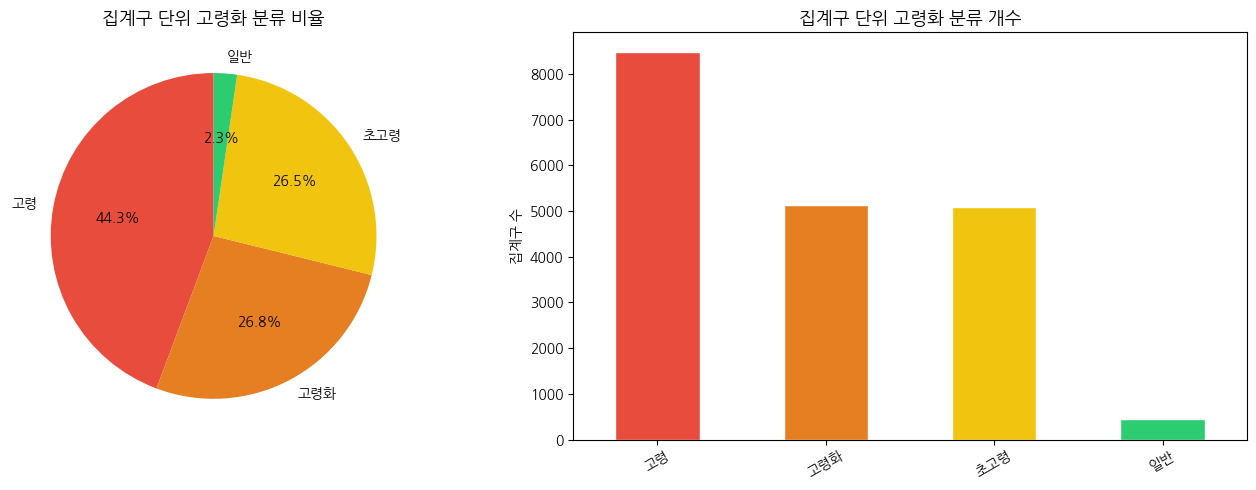

In [14]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────
# 시각화 1-A: 고령화 카테고리 분포 (파이 + 막대)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df['aging_category'].value_counts()

# 파이차트
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71'], startangle=90)
axes[0].set_title('집계구 단위 고령화 분류 비율', fontsize=13, fontweight='bold')

# 막대차트
cat_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'],
                edgecolor='white')
axes[1].set_title('집계구 단위 고령화 분류 개수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('집계구 수')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/결과_고령화분류.png', dpi=150, bbox_inches='tight')
plt.show()

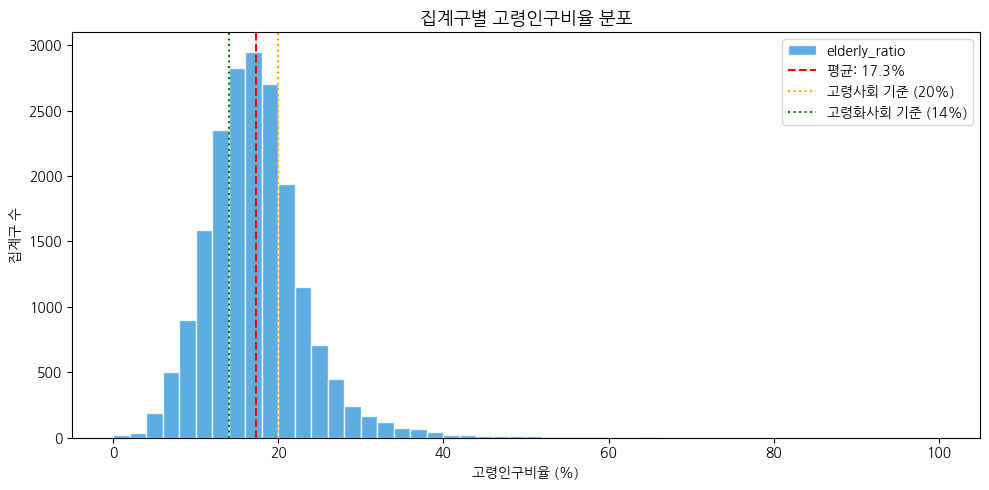

In [15]:
# ─────────────────────────────────────────────
# 시각화 1-B: 고령인구비율 분포 히스토그램
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

df['elderly_ratio'].dropna().plot(kind='hist', bins=50, color='#3498db',
                                   edgecolor='white', alpha=0.8, ax=ax)
ax.axvline(df['elderly_ratio'].mean(), color='red', linestyle='--',
           label=f"평균: {df['elderly_ratio'].mean():.1f}%")
ax.axvline(20, color='orange', linestyle=':', label='고령사회 기준 (20%)')
ax.axvline(14, color='green', linestyle=':', label='고령화사회 기준 (14%)')

ax.set_title('집계구별 고령인구비율 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('고령인구비율 (%)')
ax.set_ylabel('집계구 수')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/결과_고령비율분포.png', dpi=150, bbox_inches='tight')
plt.show()

매핑 성공률: 9104 / 19150


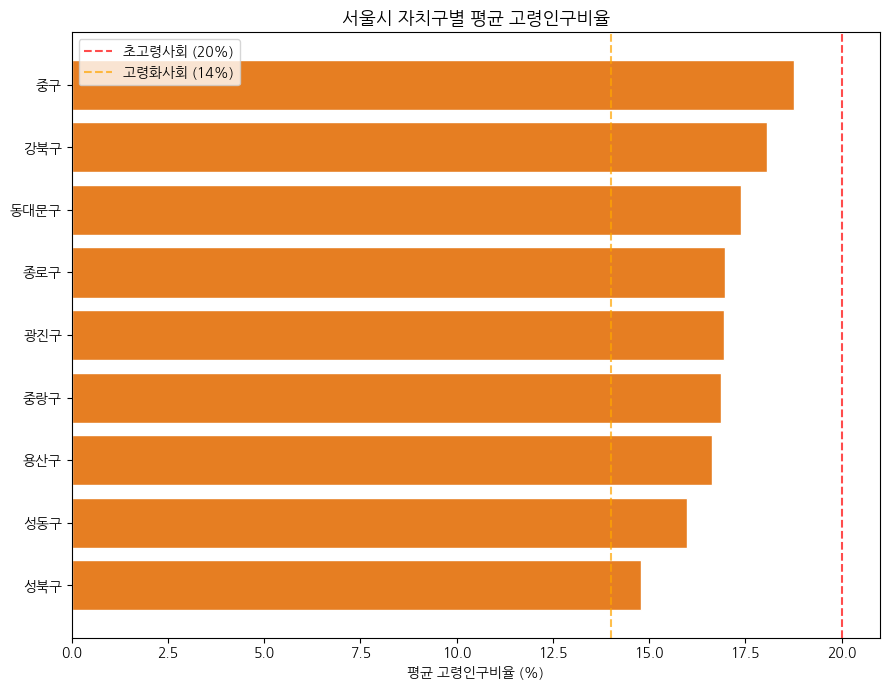

In [24]:
# ─────────────────────────────────────────────
# 시각화 1-C: 구(자치구)별 평균 고령인구비율 막대차트
# ─────────────────────────────────────────────

# 3번째 자리 1→0 으로 변환 후 앞 7자리로 매핑 ★★★
df['adm_cd_key'] = df['adstrd_code_se'].str[:7].str[:2] + '0' + df['adstrd_code_se'].str[3:7]

# 매핑 확인
adm_to_sigungu = gdf_haeng.set_index('ADM_CD')[['SIGUNGU_CD','SIGUNGU_NM']].to_dict('index')
df['SIGUNGU_NM'] = df['adm_cd_key'].map(lambda x: adm_to_sigungu.get(x, {}).get('SIGUNGU_NM', None))
print("매핑 성공률:", df['SIGUNGU_NM'].notna().sum(), '/', len(df))

# 시각화
df_gu = df.groupby('SIGUNGU_NM')['elderly_ratio'].mean().reset_index()
df_gu = df_gu.dropna(subset=['SIGUNGU_NM'])
df_gu = df_gu.sort_values('elderly_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))  # 크기 줄임
colors = ['#e74c3c' if v >= 20 else '#e67e22' if v >= 14 else '#2ecc71'
          for v in df_gu['elderly_ratio']]
ax.barh(df_gu['SIGUNGU_NM'], df_gu['elderly_ratio'], color=colors, edgecolor='white')
ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='초고령사회 (20%)')
ax.axvline(14, color='orange', linestyle='--', alpha=0.7, label='고령화사회 (14%)')
ax.set_title('서울시 자치구별 평균 고령인구비율', fontsize=13, fontweight='bold')
ax.set_xlabel('평균 고령인구비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# 매핑 안 된 값 확인
missed = df[df['SIGUNGU_NM'].isna()]['adm_cd_key'].unique()[:10]
print("매핑 안 된 adm_cd_key 샘플:", missed.tolist())
print("ADM_CD 샘플:", gdf_haeng['ADM_CD'].unique()[:10].tolist())

매핑 안 된 adm_cd_key 샘플: ['1101051', '1101065', '1104060', '1104061', '1104063', '1104064', '1107051', '1107053', '1107058', '1107063']
ADM_CD 샘플: ['1101053', '1101054', '1101055', '1101056', '1101057', '1101058', '1101060', '1101061', '1101063', '1101064']


In [26]:
# 실제로 shp에 없는 코드인지 확인
print("매핑 안 된 고유 adm_cd_key 수:", df[df['SIGUNGU_NM'].isna()]['adm_cd_key'].nunique())
print("ADM_CD 고유값 수:", gdf_haeng['ADM_CD'].nunique())


매핑 안 된 고유 adm_cd_key 수: 149
ADM_CD 고유값 수: 424


In [27]:
# 어느 구가 빠져있는지 확인
mapped_gu = df[df['SIGUNGU_NM'].notna()]['SIGUNGU_NM'].unique()
print("매핑된 구 목록:", sorted(mapped_gu.tolist()))
print("매핑된 구 수:", len(mapped_gu))

매핑된 구 목록: ['강북구', '광진구', '동대문구', '성동구', '성북구', '용산구', '종로구', '중구', '중랑구']
매핑된 구 수: 9
